In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris

In [17]:
# Load dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({i: name for i, name in enumerate(iris.target_names)})

**A**. Eksplorasi Data Awal


In [18]:
# 1. Informasi Dataset
print(f"Jumlah data: {len(df)}")
print(f"Jumlah variabel: {df.shape[1]}")
print("\nTipe data tiap variabel:")
print(df.dtypes)
print("\nJumlah masing-masing spesies:")
print(df['species_name'].value_counts())

Jumlah data: 150
Jumlah variabel: 6

Tipe data tiap variabel:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object

Jumlah masing-masing spesies:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [5]:
# 2. Statistik Deskriptif
# Menghitung mean, median, std, min, max untuk variabel numerik
print("\nStatistik Deskriptif:")
print(df.describe().loc[['mean', '50%', 'std', 'min', 'max']])


Statistik Deskriptif:
      sepal length (cm)  sepal width (cm)  petal length (cm)  \
mean           5.843333          3.057333           3.758000   
50%            5.800000          3.000000           4.350000   
std            0.828066          0.435866           1.765298   
min            4.300000          2.000000           1.000000   
max            7.900000          4.400000           6.900000   

      petal width (cm)   species  
mean          1.199333  1.000000  
50%           1.300000  1.000000  
std           0.762238  0.819232  
min           0.100000  0.000000  
max           2.500000  2.000000  


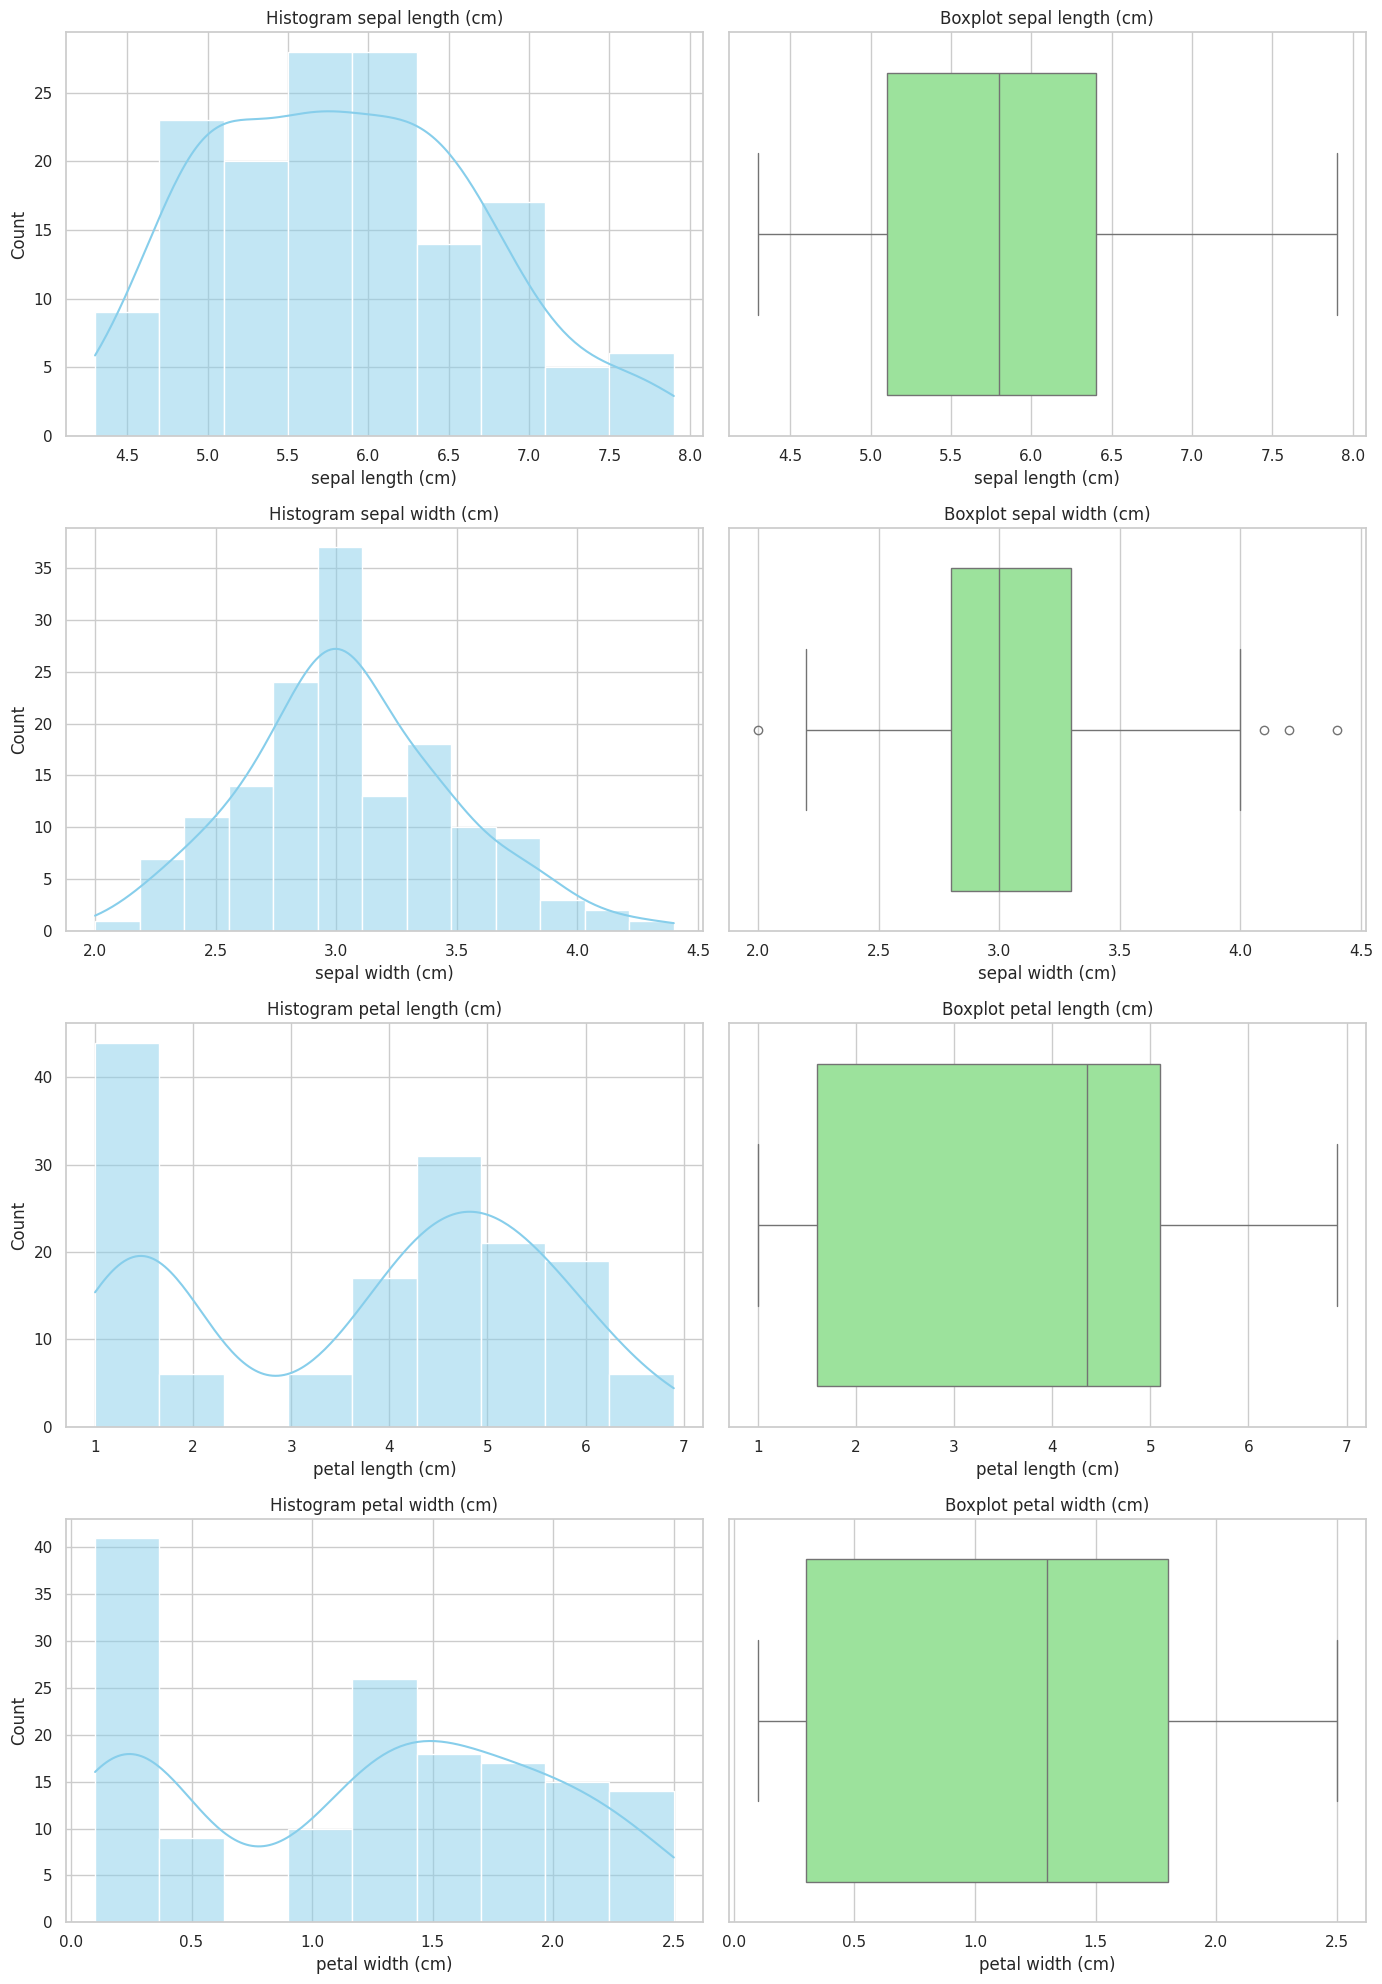

In [19]:
# Histogram & Boxplot
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
for i, col in enumerate(iris.feature_names):
    # 1. Visualisasi Histogram (Distribusi)
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Histogram {col}')

    # 2. Visualisasi Boxplot (Sebaran & Outlier)
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

1. Sepal Length

*   Bentuk Distribusi =

Hasil distribusi pada grafik diatas cenderung mendekati normal namun sedikit landai ke arah kanan. Dengan nilai yang pada grafik berada pada area nilai 5,5 hingga 6,5 cm

* Sebaran Data

Sebaran data pada variabel ini tergolong kontinu dan cukup luas, dengan nilai minimum sebesar 4,3 cm dan nilai maksimum mencapai 7,9 cm

* Outlier

Berdasarkan hasil grafik diatas, variabel sepal length tidak terdapat outlier

2. Sepal Width

* Bentuk Distribusi

Variabel sepal width menunjukkan hasil distribusi mendekati kurva normal dan simestris. Dengan nilai distribusinya sebesar 3,0 cm

* Sebaran Data

Sebaran data pada variabel ini, menunjukkan hasil yang relatif sempit dengan nilai 2,8 cm hingga 3,3 cm

* Outlier

Pada grafik variabel ini, menunjukkan hasil bahwa terdapat outlier yang berada di luar batas atas dan batas bawah whiskers

3. Petal Length

* Bentuk Distribusi

Distribusi yang terdapat pada variabel petal length bersifat bimodal (distribusi data yang memiliki 2 puncak)

* Sebaran Data

Hasil sebaran data varibel ini cenderung tidak seragam dan mencakup rentang nilai yang relatif luas, yaitu mulai dari 1,0 cm hingga 6,9 cm

* Outlier

seluruh nilai pengamatan masih berada di dalam batas garis whiskers, sehingga tidak teridentifikasi adanya outlier

4. Petal Width

* Bentuk Distribusi

Distribusi pada variabel petal width menunjukkan pola dua kelompok data, yang serupa dengan karakteristik petal length. Data cenderung terkonsentrasi pada nilai rendah, terutama di bawah 0,5 cm, sementara pada nilai yang lebih tinggi distribusinya terlihat lebih menyebar

* Sebaran Data

Nilai petal width tersebar mulai dari 0,1 cm hingga 2,5 cm, yang menandakan variasi data yang cukup besar di antara pengamatan

* Outlier

Berdasarkan visualisasi boxplot, seluruh titik data masih berada dalam batas yang ditentukan oleh whiskers, sehingga dapat disimpulkan bahwa tidak terdapat outlier pada variabel petal width.




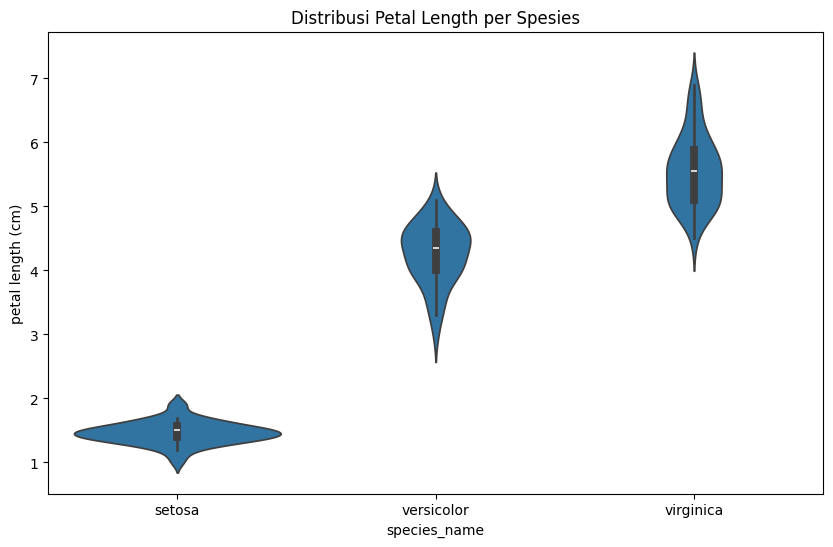

In [7]:
# Violin Plot per Spesies
plt.figure(figsize=(10, 6))
sns.violinplot(x='species_name', y='petal length (cm)', data=df)
plt.title('Distribusi Petal Length per Spesies')
plt.show()

**Perbedaan Antar Spesies**

1. Iris Setosa
* Ukuran
Spesies Iris setosa memiliki panjang petal paling kecil dibandingkan spesies lainnya, dengan rentang nilai yang sangat terbatas, yaitu sekitar 1 cm hingga 2 cm.

* Distribusi
Visualisasi violin menunjukkan bentuk yang pendek dan melebar, yang mengindikasikan bahwa data Setosa sangat terkonsentrasi dan memiliki tingkat variasi yang rendah.

* Pemisahan
Secara visual, Iris setosa terpisah secara jelas dari dua spesies lainnya. Hal ini menjadikan spesies ini paling mudah dikenali hanya dengan menggunakan variabel petal length.

2. Iris Versicolor
* Ukuran
Iris versicolor memiliki ukuran petal kategori menengah, dengan nilai rata-rata petal length berada pada kisaran 4 cm hingga 5 cm.

* Distribusi
Sebaran data pada spesies ini terlihat lebih luas dibandingkan Setosa, dengan tingkat kepadatan tertinggi berada di sekitar nilai 4,5 cm, sebagaimana ditunjukkan oleh bagian violin yang paling lebar.

* Pemisahan
Terdapat sedikit tumpang tindih (overlap) antara bagian atas distribusi Versicolor dan bagian bawah distribusi Virginica, yang menunjukkan adanya kemiripan karakteristik pada rentang nilai tertentu.

3. Iris Virginica
* Ukuran
Iris virginica merupakan spesies dengan panjang petal terbesar, di mana sebagian besar data berada di atas 5 cm dan bahkan mencapai nilai lebih dari 7 cm.

* Distribusi
Spesies ini memiliki tingkat variasi data yang paling tinggi, yang tercermin dari bentuk violin yang lebih memanjang secara vertikal dibandingkan dua spesies lainnya.

* Pemisahan
Meskipun memiliki ukuran petal yang relatif besar, Iris virginica masih menunjukkan kemiripan karakteristik dengan Versicolor pada beberapa rentang nilai, sehingga pemisahan antara kedua spesies tersebut tidak sepenuhnya tegas.



In [8]:
target_var = df['petal length (cm)']
original_mean = target_var.mean()

**Sampling (Bootstrap)**

In [9]:
# 1. Bootstrap Tunggal
# Ukuran sampel sama dengan data asli dengan pengembalian
boot_single = target_var.sample(n=len(target_var), replace=True)
print(f"Mean Bootstrap Tunggal: {boot_single.mean()}")
print(f"Mean Data Asli: {original_mean}")

Mean Bootstrap Tunggal: 3.660666666666666
Mean Data Asli: 3.7580000000000005


In [11]:
# 2. Bootstrap Berulang
def do_bootstrap(data, iterations):
    means = []
    for _ in range(iterations):
        sample = data.sample(n=len(data), replace=True)
        means.append(sample.mean())
    return means

means_100 = do_bootstrap(target_var, 100)
means_1000 = do_bootstrap(target_var, 1000)
means_10000 = do_bootstrap(target_var, 10000)

In [12]:
# 4. Interval Kepercayaan 95% (Persentil 2.5% & 97.5%)
def get_ci(means):
    return np.percentile(means, [2.5, 97.5])

print(f"CI 95% (100): {get_ci(means_100)}")
print(f"CI 95% (1000): {get_ci(means_1000)}")
print(f"CI 95% (10000): {get_ci(means_10000)}")

CI 95% (100): [3.51493333 4.02781667]
CI 95% (1000): [3.474 4.04 ]
CI 95% (10000): [3.478      4.03733333]


**Perbandingan dan Analisis**

1. Apakah mean bootstrap mendekati mean data asli?

Ya, nilai rata-rata hasil bootstrap cenderung mendekati mean data asli. Hal ini disebabkan karena sampel bootstrap diambil langsung dari data awal. Oleh karena itu, ketika proses bootstrap dilakukan secara berulang, pusat distribusi dari mean bootstrap akan terkonsentrasi di sekitar nilai rata-rata data asli.

2. Bagaimana perubahan distribusi saat jumlah bootstrap bertambah?

Ketika jumlah iterasi bootstrap meningkat, misalnya dari 100 hingga 10.000 kali, distribusi mean sampel mengalami beberapa perubahan, yaitu:

* Menjadi lebih halus,
karena ketidakteraturan pada histogram semakin berkurang.

* Semakin mendekati distribusi normal,
sesuai dengan prinsip Central Limit Theorem yang menyatakan bahwa distribusi rata-rata sampel akan membentuk pola lonceng yang simetris.

* Lebih konsisten,
di mana bentuk distribusi tidak banyak berubah meskipun proses bootstrap dijalankan berulang kali.
3. Mana yang lebih stabil: 100, 1000, atau 10000?

Jumlah iterasi 10.000 kali bootstrap menghasilkan estimasi yang paling stabil.

Hal ini dikarenakan semakin besar jumlah simulasi yang dilakukan, maka variansi dan kesalahan standar dari estimasi bootstrap akan semakin kecil, sehingga hasil yang diperoleh menjadi lebih presisi dan dapat diandalkan dibandingkan dengan jumlah iterasi yang lebih sedikit.

4. Apakah mean asli berada dalam interval kepercayaan?

Ya, mean data asli berada di dalam interval kepercayaan 95% yang diperoleh dari hasil bootstrap.

Interval kepercayaan 95% dirancang untuk mencakup nilai parameter populasi, yang dalam konteks ini diwakili oleh mean data asli, pada sebagian besar hasil simulasi bootstrap yang dilakukan.

5. Mengapa satu data bisa muncul berkali-kali pada bootstrap?
Hal ini terjadi karena metode bootstrap menerapkan sampling dengan pengembalian (sampling with replacement).

Pada setiap proses pengambilan sampel, data yang telah terpilih tetap dikembalikan ke dalam kumpulan data awal, sehingga pada pengambilan berikutnya, data yang sama masih memiliki peluang untuk terpilih kembali. Mekanisme ini memungkinkan terbentuknya sampel baru dengan ukuran yang sama seperti data asli, namun dengan komposisi yang bervariasi.


**Kesimpulan**

*   Insight Utama dari EDA Dataset Iris

Hasil eksplorasi data menunjukkan bahwa dimensi kelopak bunga, khususnya petal length dan petal width, memiliki kemampuan pemisahan yang sangat kuat antar spesies. Kedua variabel tersebut terbukti menjadi fitur utama yang paling efektif dalam proses klasifikasi.

Selain itu, distribusi variabel petal memperlihatkan pola multimodal, yang ditandai oleh adanya celah nilai yang memisahkan kelompok data antar spesies secara jelas. Temuan ini menguatkan peran variabel petal sebagai pembeda utama antar kelas. Sementara itu, berdasarkan hasil boxplot, sepal width menjadi satu-satunya variabel yang teridentifikasi memiliki pencilan (outlier).

*   Karakteristik Tiap Spesies (Berdasarkan Visualisasi)


a. Iris Setosa
Spesies ini memiliki ukuran kelopak yang paling kecil dan homogen, dengan tingkat konsentrasi data yang tinggi. Secara visual, Setosa terpisah sepenuhnya dari dua spesies lainnya sehingga sangat mudah dikenali.

b. Iris Versicolor
Versicolor menunjukkan ukuran kelopak kategori menengah dengan tingkat variasi yang sedang. Visualisasi memperlihatkan adanya sedikit tumpang tindih dengan Iris Virginica, khususnya pada variabel panjang kelopak.

c. Iris Virginica
Spesies ini memiliki ukuran kelopak paling besar, baik dari sisi panjang maupun lebar, serta tingkat variabilitas data tertinggi dibandingkan spesies lainnya.

*   Manfaat Bootstrap dalam Analisis Data

**Manfaat Bootstrap**

a. Dapat Mengestimasi Ketidakpastian
Metode ini memungkinkan perhitungan interval kepercayaan tanpa mengharuskan adanya asumsi kuat mengenai bentuk distribusi populasi.

b. Validasi Statistik
Bootstrap membantu mengevaluasi kestabilan statistik deskriptif, seperti mean dan median, melalui proses resampling yang dilakukan secara berulang.

c. Efisiensi Penggunaan Data
Teknik ini sangat bermanfaat ketika ukuran data terbatas, karena memungkinkan simulasi distribusi statistik hanya dengan memanfaatkan data yang tersedia.

*   Jumlah Bootstrap yang Cukup
Berdasarkan hasil analisis, jumlah 10.000 iterasi bootstrap dinilai sebagai jumlah yang paling optimal.

Pada tingkat iterasi ini, distribusi mean bootstrap menjadi lebih stabil dan halus, mendekati distribusi normal, serta menghasilkan interval kepercayaan yang lebih presisi dan konsisten dibandingkan dengan penggunaan 100 atau 1.000 iterasi.




